In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df=pd.read_csv('height-weight.csv')


In [3]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


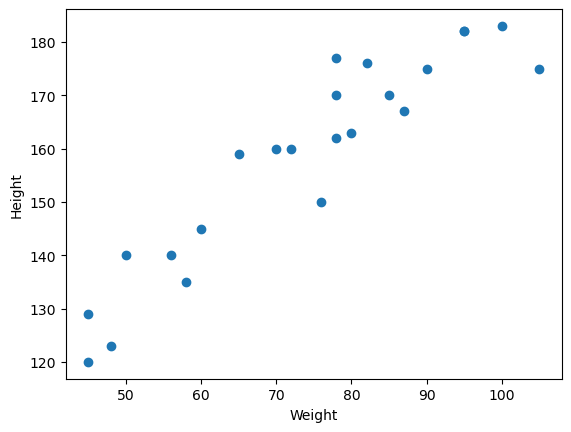

In [4]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

In [5]:
#dividing into independent and dependent
X=df[['Weight']] #independent
Y=df[['Height']] #dependent


In [6]:
#train test split
from sklearn.model_selection import train_test_split

In [7]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.20,random_state=42)

In [8]:
X.shape

(23, 1)

In [9]:
X_train.shape

(18, 1)

In [10]:
#standardization the dataset train independent
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [11]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

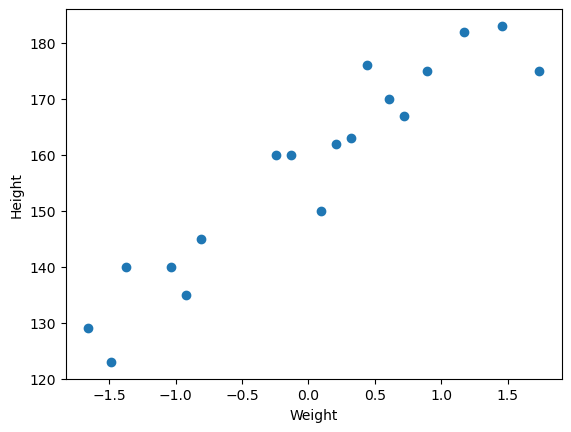

In [12]:
plt.scatter(X_train,Y_train)
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show() 

In [13]:
#train  simple linear regression model
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()

In [14]:
regressor.fit(X_train,Y_train)

LinearRegression()

In [15]:
regressor.coef_

array([[17.03440872]])

In [16]:
regressor.intercept_

array([157.5])

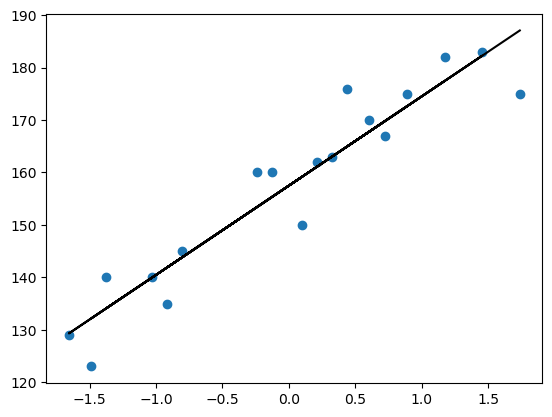

In [17]:
plt.scatter(X_train,Y_train)
plt.plot(X_train,regressor.predict(X_train),color='black')
plt.show()

In [18]:
#prediction of train data
Y_pred_test=regressor.predict(X_test)
Y_pred_test,Y_test

(array([[161.08467086],
        [161.08467086],
        [129.3041561 ],
        [177.45645118],
        [148.56507414]]),
     Height
 15     177
 9      170
 0      120
 8      182
 17     159)

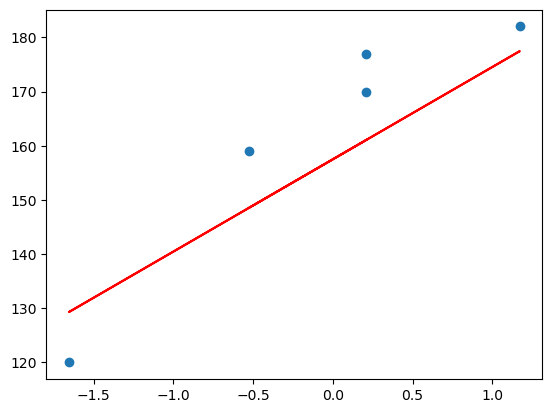

In [19]:
plt.scatter(X_test,Y_test)
plt.plot(X_test,regressor.predict(X_test),'r')
plt.show()

In [20]:
##performance metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [21]:
mse=mean_squared_error(Y_test,Y_pred_test)
mae=mean_absolute_error(Y_test,Y_pred_test)
rmse=np.sqrt(mse)
score=r2_score(Y_test,Y_pred_test)
print(mse,mae,rmse)
print(score*100)

109.77592599051664 9.822657814519232 10.477400726827081
77.6986986042344


In [22]:
#adjusted r2
adj_r2=1-(1-score)*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1)
print(adj_r2*100)

70.26493147231253


In [23]:
##new data point weight = 80 kg
scaled_weight=scaler.transform([[80]])
scaled_weight

c:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

In [24]:
scaled_weight[0]
print(regressor.predict([scaled_weight[0]]))


[[163.01076266]]


In [25]:
#resuidal
residuals=Y_test-Y_pred_test
residuals

,Height
15,15.915329
9,8.915329
0,-9.304156
8,4.543549
17,10.434926


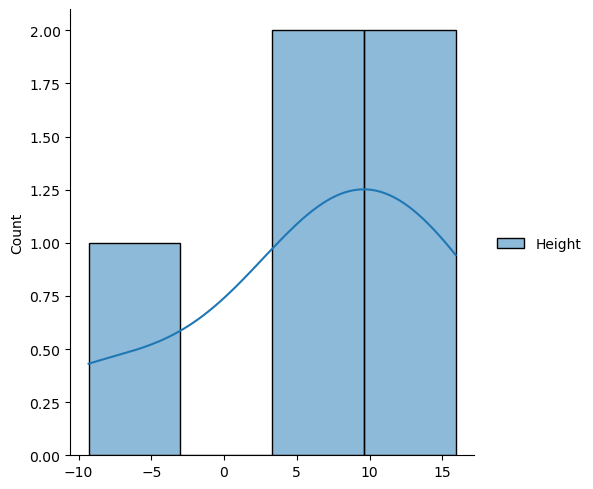

In [26]:
#plot this residuals
import seaborn as sns
sns.displot(residuals,kde=True)
plt.show()

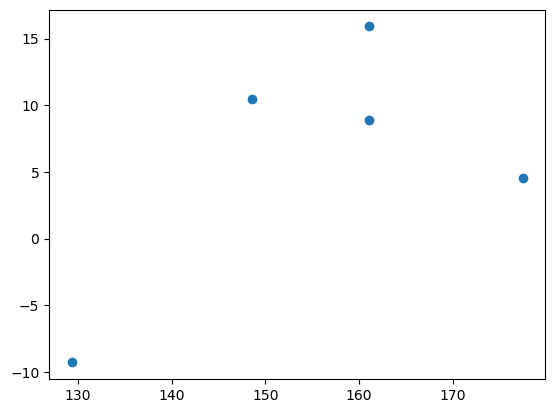

In [27]:
#scatter plot with respect to prediction and residuals
#uniform distribution
plt.scatter(Y_pred_test,residuals)

plt.show()